In [51]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\visha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn import metrics as mlt
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

In [86]:
# load dataset
df=pd.read_csv('bank-full.csv', sep=";")

In [87]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [88]:
df.shape

(45211, 17)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [90]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


# EDA

In [91]:
cols= df.columns
for col in cols:
    print(df.value_counts(df[col]),end="\n next line")



age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
92       2
93       2
88       2
94       1
Name: count, Length: 77, dtype: int64
 next linejob
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
 next linemarital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
 next lineeducation
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
 next linedefault
no     44396
yes      815
Name: count, dtype: int64
 next linebalance
0        3514
1         195
2         156
4         139
3         134
         ... 
7038        1
9710        1
8205        1
14204       1
16353       1
Name: count, Length: 7168, dtype: int64
 next linehousing
yes    25130


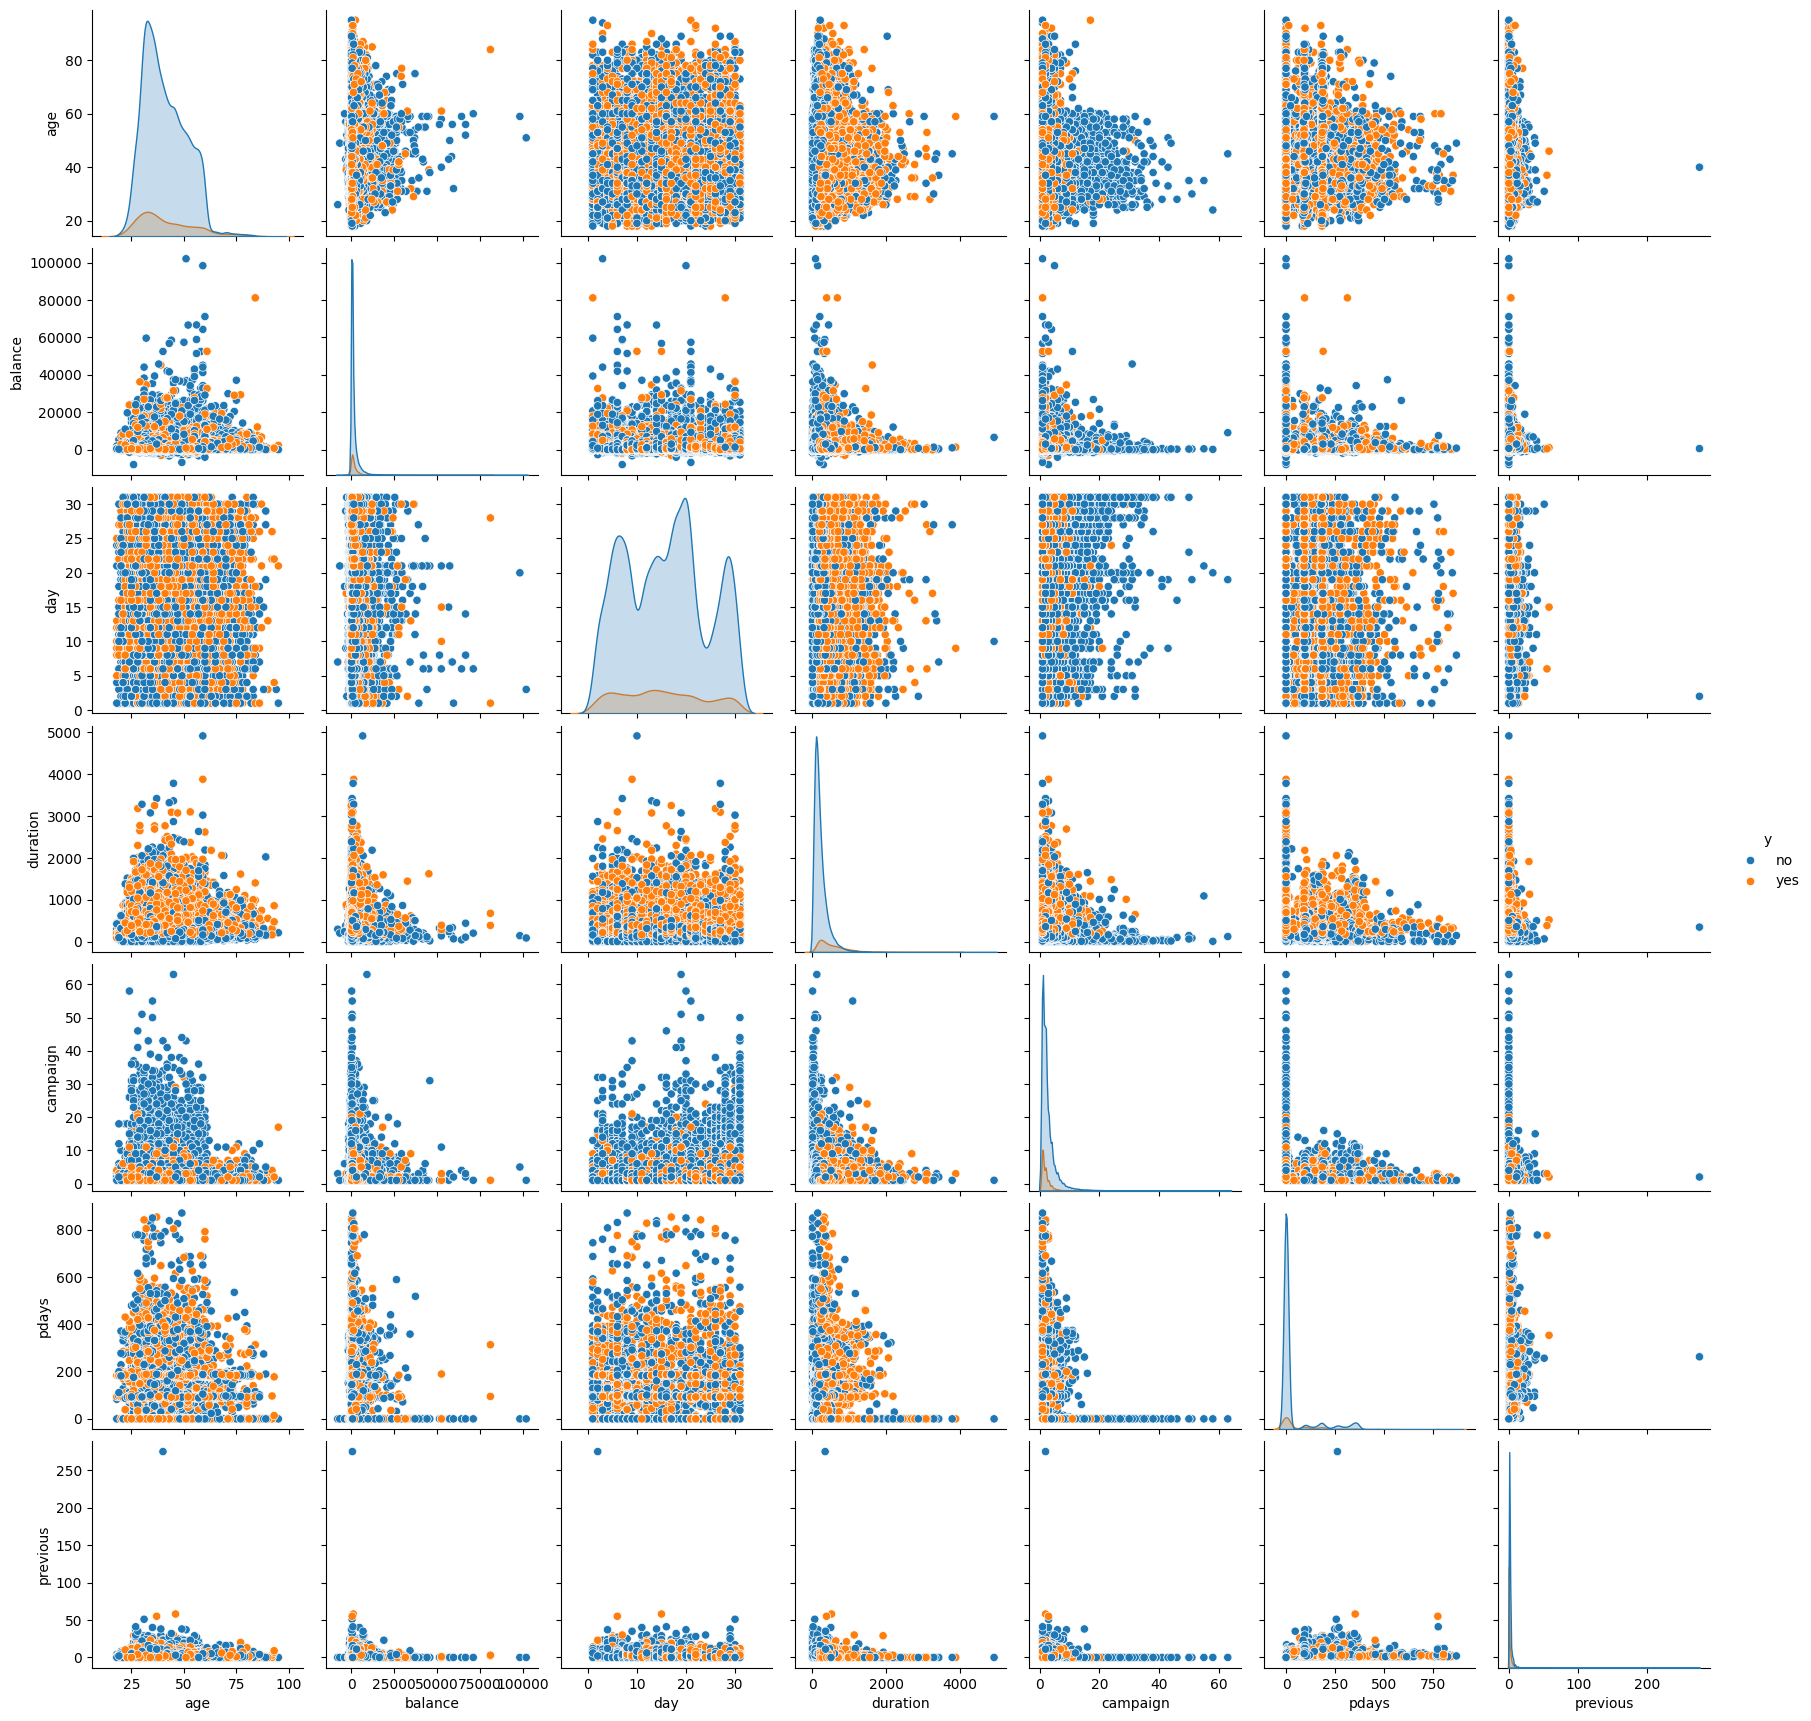

In [59]:
# cheaking realtion of all columns
sns.pairplot(df, hue="y")
plt.show()

In [92]:
df.value_counts("y")

y
no     39922
yes     5289
Name: count, dtype: int64

<Axes: xlabel='y', ylabel='count'>

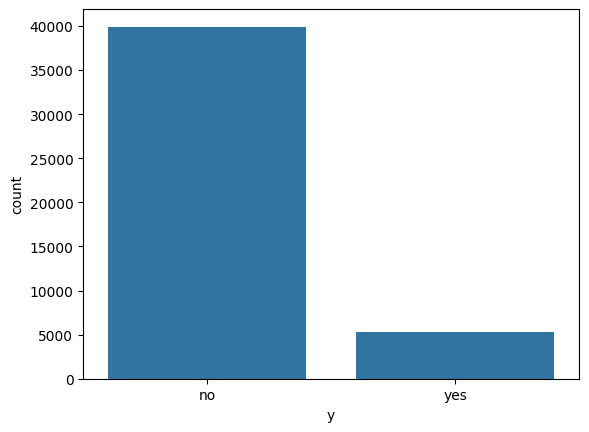

In [93]:
sns.barplot(df.value_counts("y"))

In [94]:
#  ENCODE THE TARGET VARIABLE 
df['y']=df['y'].map({'no':0,'yes':1})



In [95]:
# esatblish the X and y
X=df.drop('y', axis=1)
y=df['y']

In [99]:
# one hot code
X= pd.get_dummies(X,drop_first=True)

In [100]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [101]:
# now importing shote 
s=SMOTE(random_state=42)
X_train_s,y_train_s =s.fit_resample(X_train,y_train)

In [ ]:
dc_model=DecisionTreeClassifier()
dc_model.fit(X_train_s,y_train_s)
y_pred=dc_model.predict(X_test)


In [105]:
# printing the Accuracy
print("Accuracy Score:", mlt.accuracy_score(y_test,y_pred))
print("\nClassification Report:")
print(mlt.classification_report(y_test, y_pred))

Accuracy Score: 0.8690699988941722

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7952
           1       0.46      0.51      0.49      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.87      0.87      9043



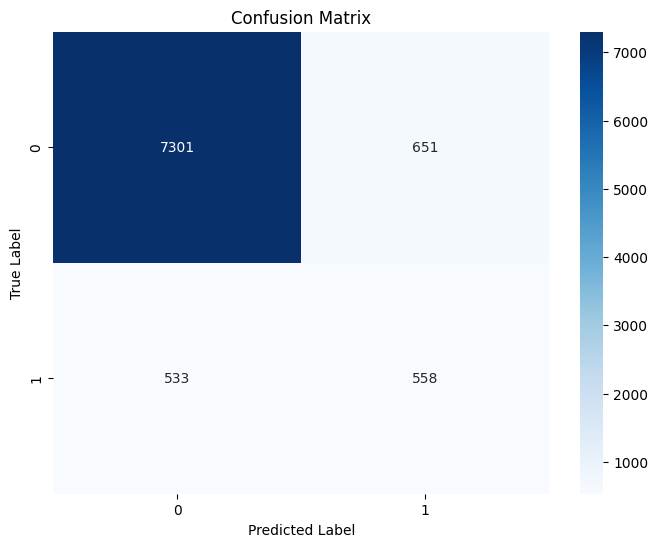

In [106]:
plt.figure(figsize=(8, 6))
sns.heatmap(mlt.confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()